# Data AND LIBRARY PREPARATION

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load data
# -----------------------------
# 0) Load + merge
# -----------------------------
MP3_PATH = "./data/RL_Data_FullResults_202511281950_mp3.csv"
AAC_PATH = "./data/RL_Data_FullResults_202512051033_aac.csv"
NC_PATH  = "./data/RL_Data_FullResults_202512111058_nc.csv"

mp3 = pd.read_csv(MP3_PATH); mp3["codec"] = "mp3"
aac = pd.read_csv(AAC_PATH); aac["codec"] = "aac"
nc  = pd.read_csv(NC_PATH);  nc["codec"]  = "nc"

df = pd.concat([mp3, aac, nc], ignore_index=True)

REWARD_COL = "reward"
CODEC_COL  = "codec"

if REWARD_COL not in df.columns:
    raise ValueError(f"Expected '{REWARD_COL}' column. Found: {df.columns.tolist()[:30]} ...")
    

# -----------------------------
# 1) Codec-wise StandardScaler reward scaling (row-safe)
# -----------------------------
df["reward_scaled"] = np.nan

for codec, idx in df.groupby(CODEC_COL).groups.items():
    r = df.loc[idx, REWARD_COL].to_numpy().reshape(-1, 1)
    df.loc[idx, "reward_scaled"] = StandardScaler().fit_transform(r).ravel()

# Safety check
if df["reward_scaled"].isna().any():
    bad = df[df["reward_scaled"].isna()][CODEC_COL].value_counts()
    raise ValueError(f"reward_scaled has NaNs after scaling. Problem codecs:\n{bad}")


# -----------------------------
# 2) Build X / y (NO codec in X)
# -----------------------------
exclude_cols = {REWARD_COL, "reward_scaled", CODEC_COL}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

if not feature_cols:
    raise ValueError("No numeric features found after exclusions; check CSV numeric dtypes.")

X = df[feature_cols]
y = df["reward_scaled"]

# XGB MODEL Configuration

In [3]:
xgb_params = {
    'n_estimators': 100,       # Boosting rounds
    'max_depth': 6,            # Tree depth
    'learning_rate': 0.1,      # Step size
    'min_child_weight': 3,     # Min samples in leaf
    'subsample': 0.8,          # Row sampling
    'colsample_bytree': 0.8,   # Feature sampling
    'reg_alpha': 0.1,          # L1 regularization
    'reg_lambda': 1.0,         # L2 regularization
    'random_state': 42
}

In [4]:
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

cv_results = {}
    
X = df[feature_cols].values
y = df["reward_scaled"].values

fold_r2, fold_rmse, fold_mae = [], [], []

for train_idx, test_idx in cv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    fold_r2.append(r2_score(y_test, y_pred))
    fold_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    fold_mae.append(mean_absolute_error(y_test, y_pred))

fold_r2 = np.array(fold_r2)
fold_rmse = np.array(fold_rmse)
fold_mae = np.array(fold_mae)

# 95% Confidence Interval
ci_lower = np.percentile(fold_r2, 2.5)
ci_upper = np.percentile(fold_r2, 97.5)

cv_results = {
    'r2_mean': fold_r2.mean(),
    'r2_std': fold_r2.std(),
    'r2_ci': (ci_lower, ci_upper),
    'rmse_mean': fold_rmse.mean(),
    'mae_mean': fold_mae.mean(),
    'r2_scores': fold_r2
}

print(f"  R² Score:    {fold_r2.mean():.4f} ± {fold_r2.std():.4f}")
print(f"  95% CI:      [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  RMSE:        {fold_rmse.mean():.4f} ± {fold_rmse.std():.4f}")
print(f"  MAE:         {fold_mae.mean():.4f} ± {fold_mae.std():.4f}")
print(f"  Variance Explained: {fold_r2.mean()*100:.1f}%")


  R² Score:    0.9679 ± 0.0027
  95% CI:      [0.9638, 0.9727]
  RMSE:        0.1787 ± 0.0083
  MAE:         0.1151 ± 0.0052
  Variance Explained: 96.8%


In [5]:
import numpy as np

print("Min:", y.min())
print("Max:", y.max())
print("Mean:", y.mean())
print("Std:", y.std())
print("5–95%:", np.percentile(y, [5, 95]))

Min: -3.6437978347818842
Max: 2.8136485652883025
Mean: -1.75442650804963e-18
Std: 1.0
5–95%: [-1.6998339  1.489632 ]


### XGBosst to check the Residual Diganose with PLOT

Purpose: Validate model assumptions and detect systematic errors

  Mean Residual:    -0.000034 (should be ≈0)
  Residual Std:     0.0898
  Skewness:         -0.0633 (should be ≈0)
  Kurtosis:         2.8044 (normal=0)
  Durbin-Watson:    1.4802 (ideal=2, no autocorr)
  Heteroscedasticity: r=-0.1389, p=3.6279e-36


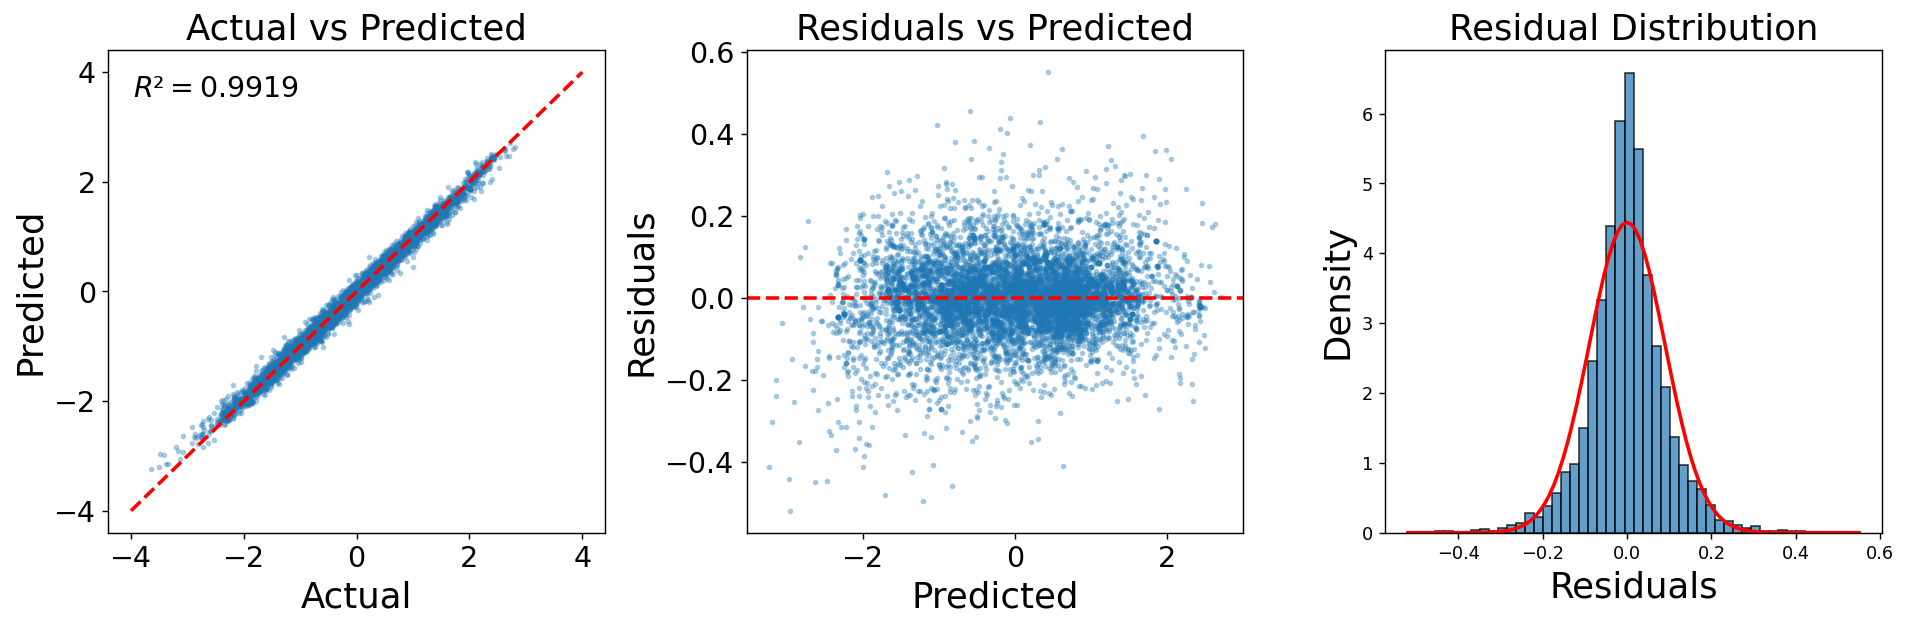

In [7]:
# =============================================================================
print("Purpose: Validate model assumptions and detect systematic errors\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=128)

    
model = XGBRegressor(**xgb_params)
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

print(f"  Mean Residual:    {residuals.mean():.6f} (should be ≈0)")
print(f"  Residual Std:     {residuals.std():.4f}")
print(f"  Skewness:         {stats.skew(residuals):.4f} (should be ≈0)")
print(f"  Kurtosis:         {stats.kurtosis(residuals):.4f} (normal=0)")

# Durbin-Watson (autocorrelation)
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
print(f"  Durbin-Watson:    {dw:.4f} (ideal=2, no autocorr)")

# Heteroscedasticity check
corr, p = spearmanr(np.abs(residuals), y_pred)
print(f"  Heteroscedasticity: r={corr:.4f}, p={p:.4e}")

# Plot: Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y, y_pred, alpha=0.3, s=5)
ax1.plot([-4, 4], [-4, 4], 'r--', lw=2)
ax1.set_xlabel('Actual', fontsize=20)
ax1.set_ylabel('Predicted', fontsize=20)
ax1.set_title(f'Actual vs Predicted', fontsize=20)
ax1.tick_params(axis='both', labelsize=16)

ax1.text(
    0.05, 0.95,
    rf"$R² = {r2_score(y, y_pred):.4f}$",
    transform=ax1.transAxes,
    fontsize=16,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

# Plot: Residuals vs Predicted
ax2 = axes[1]
ax2.scatter(y_pred, residuals, alpha=0.3, s=5)
ax2.axhline(0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted', fontsize=20)
ax2.set_ylabel('Residuals', fontsize=20)
ax2.set_title(f'Residuals vs Predicted', fontsize=20)
ax2.tick_params(axis='both', labelsize=16)

# Plot: Residual Distribution
ax3 = axes[2]
ax3.hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black')
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax3.plot(x_norm, stats.norm.pdf(x_norm, 0, residuals.std()), 'r-', lw=2)
ax3.set_xlabel('Residuals', fontsize=20)
ax3.set_ylabel('Density', fontsize=20)
ax3.set_title(f'Residual Distribution', fontsize=20)
ax2.tick_params(axis='both', labelsize=16)

plt.tight_layout()


## PERMUTATION FEATURE IMPORTANCE Table Caculation

In [5]:
print("Method: Measure R² drop when each feature is randomly shuffled")
print("Statistical Test: One-sample t-test (H₀: importance = 0)")
print("Repeats: 30 permutations per feature for confidence intervals\n")

importance_results = {}


# Fit on full data for importance analysis
model = XGBRegressor(**xgb_params)
model.fit(X, y)

# Permutation importance
perm_result = permutation_importance(
    model, X, y, n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1, scoring='r2'
)

# Build results DataFrame with statistical tests
imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std,
    'CI_Lower': np.percentile(perm_result.importances, 2.5, axis=1),
    'CI_Upper': np.percentile(perm_result.importances, 97.5, axis=1),
})

# One-sample t-test: Is importance significantly > 0?
p_values = []
for i in range(len(feature_cols)):
    t_stat, p = stats.ttest_1samp(perm_result.importances[i], 0)
    p_values.append(p/2 if t_stat > 0 else 1.0)  # One-tailed

imp_df['p_value'] = p_values
imp_df['Significant'] = imp_df['p_value'] < 0.05
imp_df = imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

importance_results = imp_df

# Display top 10
print(f"{'Rank':<5} {'Feature':<10} {'Importance':>10} {'95% CI':>20} {'p-value':>12} {'Sig':>5}")
print("-" * 65)
for i, row in imp_df.head(30).iterrows():
    sig = "***" if row['p_value'] < 0.001 else ("**" if row['p_value'] < 0.01 else ("*" if row['p_value'] < 0.05 else ""))
    print(f"{imp_df.index.get_loc(i)+1:<5} {row['Feature']:<10} {row['Importance']:>10.4f} [{row['CI_Lower']:>7.4f}, {row['CI_Upper']:>7.4f}] {row['p_value']:>12.2e} {sig:>5}")

# Cumulative importance
cumsum = imp_df['Importance'].cumsum()
total = imp_df['Importance'].sum()
n_80 = (cumsum / total < 0.8).sum() + 1
n_90 = (cumsum / total < 0.9).sum() + 1
n_sig = imp_df['Significant'].sum()

print(f"\nFeatures for 80% importance: {n_80}")
print(f"Features for 90% importance: {n_90}")
print(f"Significant features (p<0.05): {n_sig}/{len(feature_cols)}")


STEP 5: PERMUTATION FEATURE IMPORTANCE
Method: Measure R² drop when each feature is randomly shuffled
Statistical Test: One-sample t-test (H₀: importance = 0)
Repeats: 30 permutations per feature for confidence intervals

Rank  Feature    Importance               95% CI      p-value   Sig
-----------------------------------------------------------------
1     Hum1           0.2496 [ 0.2434,  0.2564]     6.17e-56   ***
2     Hiss1          0.2017 [ 0.1986,  0.2063]     1.45e-58   ***
3     Hum            0.1454 [ 0.1433,  0.1485]     2.10e-59   ***
4     Ratio1         0.1409 [ 0.1326,  0.1467]     2.79e-48   ***
5     Thre1          0.1368 [ 0.1317,  0.1441]     1.86e-48   ***
6     Hiss           0.1319 [ 0.1283,  0.1351]     1.21e-55   ***
7     Hum2           0.1038 [ 0.1014,  0.1072]     6.43e-54   ***
8     Hiss2          0.0924 [ 0.0895,  0.0950]     2.13e-52   ***
9     Ratio          0.0838 [ 0.0803,  0.0862]     1.51e-50   ***
10    Hum3           0.0728 [ 0.0710,  0.0753]   

In [9]:
cumsum / total

0     0.148414
1     0.268335
2     0.354749
3     0.438539
4     0.519848
5     0.598251
6     0.659977
7     0.714917
8     0.764719
9     0.807989
10    0.844497
11    0.879869
12    0.906608
13    0.932299
14    0.945415
15    0.955009
16    0.962344
17    0.969382
18    0.974931
19    0.979917
20    0.984592
21    0.988371
22    0.991999
23    0.994746
24    0.996885
25    0.998099
26    0.999058
27    1.000000
Name: Importance, dtype: float64